In [2]:

import preprocesamiento_prueba as pp  # archivo preprocessing.py
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter
from scipy.sparse import lil_matrix
from sklearn.decomposition import TruncatedSVD

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\raule\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\raule\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\raule\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [3]:
fake_news=pd.read_csv("D57000_complete.csv",sep=";")
fake_news.head()

,ID,Label,Titulo,Descripcion,Fecha
0,ID,1,Moreno intenta apaciguar el flanco sanitario m...,El presidente abre la puerta a unos comicios e...,19/04/2022
1,ID,1,La Abogacía del Estado se retira como acusació...,"En un escrito, la abogada del Estado Rosa Marí...",17/09/2021
2,ID,0,Las promesas incumplidas de Pablo Echenique en...,Este lunes y martes la Asamblea de Madrid acog...,12/09/2022
3,ID,1,Sánchez defiende 'resolver el problema' de la ...,Resulta evidente que la ley ha tenido algunos ...,07/02/2023
4,ID,1,Ian Gibson cierra la lista electoral de la con...,"El hispanista, que ya ocupó un puesto simbólic...",12/04/2023


In [4]:
news_corpus=fake_news.iloc[:,3].tolist()
print(f"Numero de documentos en el corpus: {len(news_corpus)}")

Numero de documentos en el corpus: 57231


In [5]:
print("Ejemplos de noticias:", news_corpus[:2])  # Muestra los primeros 2 documentos

Ejemplos de noticias: ['El presidente abre la puerta a unos comicios en junio que no sean en domingo.', 'En un escrito, la abogada del Estado Rosa María Seoane argumenta su decisión en la falta de legitimación activa respecto de los delitos imputados.']


In [6]:
labels=fake_news.iloc[:,1].tolist()

In [7]:
tokenized_corpus= [pp.preprocesar_texto(corpus, []) for corpus in news_corpus]
print(f"Preprocesamiento completado: {len(tokenized_corpus)} documentos")

Preprocesamiento completado: 57231 documentos


In [8]:
# Convertir tokens a strings para CountVectorizer y TfidfVectorizer
corpus_strings = [' '.join(tokens) for tokens in tokenized_corpus]

## Bolsa de Palabras

In [9]:
bow_vectorizer = CountVectorizer(max_features=1000)
bow_matrix = bow_vectorizer.fit_transform(corpus_strings)

print(f"Dimensiones de la matriz BoW: {bow_matrix.shape}")
print(f"Vocabulario BoW: {len(bow_vectorizer.vocabulary_)} palabras")
print(f"Sparsity: {(1.0 - bow_matrix.nnz / (bow_matrix.shape[0] * bow_matrix.shape[1])) * 100:.2f}%")

Dimensiones de la matriz BoW: (57231, 1000)
Vocabulario BoW: 1000 palabras
Sparsity: 98.84%


In [10]:
# Palabras más frecuentes
bow_sum = np.array(bow_matrix.sum(axis=0)).flatten()
bow_words = bow_vectorizer.get_feature_names_out()
top_bow = sorted(zip(bow_words, bow_sum), key=lambda x: x[1], reverse=True)[:10]
print("\nTop 10 palabras más frecuentes (BoW):")
for word, count in top_bow:
    print(f"  {word}: {int(count)}")


Top 10 palabras más frecuentes (BoW):
  gobierno: 11437
  partido: 7936
  ver: 6491
  ma: 6370
  president: 6291
  pp: 5854
  catalunya: 4919
  madrid: 4883
  ano: 4349
  si: 4118


## Construcción de TF-IDF

In [11]:
tfidf_vectorizer = TfidfVectorizer(max_features=1000)
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus_strings)

print(f"Dimensiones de la matriz TF-IDF: {tfidf_matrix.shape}")
print(f"Vocabulario TF-IDF: {len(tfidf_vectorizer.vocabulary_)} palabras")

Dimensiones de la matriz TF-IDF: (57231, 1000)
Vocabulario TF-IDF: 1000 palabras


In [12]:
# Palabras con mayor TF-IDF promedio
tfidf_mean = np.array(tfidf_matrix.mean(axis=0)).flatten()
tfidf_words = tfidf_vectorizer.get_feature_names_out()
top_tfidf = sorted(zip(tfidf_words, tfidf_mean), key=lambda x: x[1], reverse=True)[:10]
print("\nTop 10 palabras con mayor TF-IDF promedio:")
for word, score in top_tfidf:
    print(f"  {word}: {score:.4f}")


Top 10 palabras con mayor TF-IDF promedio:
  gobierno: 0.0295
  partido: 0.0232
  ver: 0.0207
  president: 0.0205
  ma: 0.0194
  pp: 0.0188
  madrid: 0.0165
  ano: 0.0148
  catalunya: 0.0148
  si: 0.0140


## Matriz de co-ocurrencia y PPMI

In [13]:
# Construir vocabulario global limitado
vocab_counter = Counter()
for tokens in tokenized_corpus:
    vocab_counter.update(tokens)

# Tomar las 1000 palabras más frecuentes
VOCAB_SIZE = 1000
most_common = vocab_counter.most_common(VOCAB_SIZE)
vocab_list = [word for word, _ in most_common]
word_to_idx = {word: idx for idx, word in enumerate(vocab_list)}

print(f"Vocabulario de co-ocurrencia: {len(vocab_list)} palabras")

Vocabulario de co-ocurrencia: 1000 palabras


In [14]:
 #construir matriz de co-ocurrencia
WINDOW_SIZE = 5
cooccurrence_matrix = lil_matrix((VOCAB_SIZE, VOCAB_SIZE), dtype=np.float32)

print(f"Construyendo matriz de co-ocurrencia (ventana={WINDOW_SIZE})...")
for doc_idx, tokens in enumerate(tokenized_corpus):
    if doc_idx % 500 == 0:
        print(f"  Procesados: {doc_idx}/{len(tokenized_corpus)}")
    
    for i, token in enumerate(tokens):
        if token not in word_to_idx:
            continue
        
        token_idx = word_to_idx[token]
        
        # Ventana de contexto
        start = max(0, i - WINDOW_SIZE)
        end = min(len(tokens), i + WINDOW_SIZE + 1)
        
        for j in range(start, end):
            if i == j:
                continue
            context_token = tokens[j]
            if context_token in word_to_idx:
                context_idx = word_to_idx[context_token]
                cooccurrence_matrix[token_idx, context_idx] += 1

cooccurrence_matrix = cooccurrence_matrix.tocsr()
print(f"Matriz de co-ocurrencia construida: {cooccurrence_matrix.shape}")
print(f"Entradas no-cero: {cooccurrence_matrix.nnz}")


Construyendo matriz de co-ocurrencia (ventana=5)...
  Procesados: 0/57231
  Procesados: 500/57231
  Procesados: 1000/57231
  Procesados: 1500/57231
  Procesados: 2000/57231
  Procesados: 2500/57231
  Procesados: 3000/57231
  Procesados: 3500/57231
  Procesados: 4000/57231
  Procesados: 4500/57231
  Procesados: 5000/57231
  Procesados: 5500/57231
  Procesados: 6000/57231
  Procesados: 6500/57231
  Procesados: 7000/57231
  Procesados: 7500/57231
  Procesados: 8000/57231
  Procesados: 8500/57231
  Procesados: 9000/57231
  Procesados: 9500/57231
  Procesados: 10000/57231
  Procesados: 10500/57231
  Procesados: 11000/57231
  Procesados: 11500/57231
  Procesados: 12000/57231
  Procesados: 12500/57231
  Procesados: 13000/57231
  Procesados: 13500/57231
  Procesados: 14000/57231
  Procesados: 14500/57231
  Procesados: 15000/57231
  Procesados: 15500/57231
  Procesados: 16000/57231
  Procesados: 16500/57231
  Procesados: 17000/57231
  Procesados: 17500/57231
  Procesados: 18000/57231
  Procesad

In [15]:
# Calcular PPMI (Positive Pointwise Mutual Information)
print("\nCalculando PPMI...")

# Convertir a array denso para el cálculo (solo para vocabulario reducido)
cooc_dense = cooccurrence_matrix.toarray()

# Totales
total = cooc_dense.sum()
row_sums = cooc_dense.sum(axis=1, keepdims=True)
col_sums = cooc_dense.sum(axis=0, keepdims=True)

# Evitar división por cero
row_sums[row_sums == 0] = 1
col_sums[col_sums == 0] = 1

# PMI = log(P(w,c) / (P(w) * P(c)))
p_wc = cooc_dense / total
p_w = row_sums / total
p_c = col_sums / total

# Evitar log(0)
with np.errstate(divide='ignore', invalid='ignore'):
    pmi_matrix = np.log2(p_wc / (p_w * p_c))
    pmi_matrix[np.isnan(pmi_matrix)] = 0
    pmi_matrix[np.isinf(pmi_matrix)] = 0

# PPMI: max(PMI, 0)
ppmi_matrix = np.maximum(pmi_matrix, 0)

print(f"Matriz PPMI construida: {ppmi_matrix.shape}")
print(f"Valores PPMI no-cero: {np.count_nonzero(ppmi_matrix)}")
print(f"PPMI máximo: {ppmi_matrix.max():.4f}")
print(f"PPMI promedio (valores > 0): {ppmi_matrix[ppmi_matrix > 0].mean():.4f}")


Calculando PPMI...
Matriz PPMI construida: (1000, 1000)
Valores PPMI no-cero: 338937
PPMI máximo: 8.5222
PPMI promedio (valores > 0): 1.0678


In [16]:
# Crear vectores de documentos con PPMI
ppmi_doc_vectors = []
for tokens in tokenized_corpus:
    token_indices = [word_to_idx[token] for token in tokens if token in word_to_idx]
    if token_indices:
        ppmi_doc_vectors.append(np.mean(ppmi_matrix[token_indices], axis=0))
    else:
        ppmi_doc_vectors.append(np.zeros(VOCAB_SIZE))
ppmi_doc_matrix = np.array(ppmi_doc_vectors)

## Implementacion de Embeedings

### SVD/LSA

In [17]:
#SVD/LSA 
# Aplicar SVD a la matriz TF-IDF
n_components_svd = 100
svd = TruncatedSVD(n_components=n_components_svd, random_state=42)
lsa_doc_matrix = svd.fit_transform(tfidf_matrix)

print(f"Matriz de documentos LSA: {lsa_doc_matrix.shape}")
print(f"Varianza explicada: {svd.explained_variance_ratio_.sum():.4f}")

Matriz de documentos LSA: (57231, 100)
Varianza explicada: 0.2702


In [18]:
# Obtener embeddings de palabras desde los componentes
lsa_word_embeddings = svd.components_.T  # (vocab_size x n_components)
print(f"Embeddings de palabras LSA: {lsa_word_embeddings.shape}")

# Palabras más relevantes por componente
feature_names = tfidf_vectorizer.get_feature_names_out()
print("\nTop 5 palabras por componente (primeros 3 componentes):")
for i in range(min(3, n_components_svd)):
    top_indices = np.argsort(svd.components_[i])[-5:][::-1]
    top_words = [feature_names[idx] for idx in top_indices]
    print(f"  Componente {i}: {', '.join(top_words)}")

Embeddings de palabras LSA: (1000, 100)

Top 5 palabras por componente (primeros 3 componentes):
  Componente 0: ver, gobierno, catalunya, partido, iniciativa
  Componente 1: ver, iniciativa, catalunya, equo, boluart
  Componente 2: gobierno, president, sanchez, ejecutivo, lider


### Glove Simplificado

In [19]:
# Aplicar SVD a la matriz de co-ocurrencia (similar a GloVe)
n_components_glove = 100
svd_glove = TruncatedSVD(n_components=n_components_glove, random_state=42)
glove_word_embeddings = svd_glove.fit_transform(cooccurrence_matrix)

print(f"Embeddings de palabras GloVe: {glove_word_embeddings.shape}")
print(f"Varianza explicada: {svd_glove.explained_variance_ratio_.sum():.4f}")

Embeddings de palabras GloVe: (1000, 100)
Varianza explicada: 0.9656


In [20]:
# Crear vectores de documentos promediando embeddings de palabras
glove_doc_vectors = []
for tokens in tokenized_corpus:
    token_indices = [word_to_idx[token] for token in tokens if token in word_to_idx]
    if token_indices:
        glove_doc_vectors.append(np.mean(glove_word_embeddings[token_indices], axis=0))
    else:
        glove_doc_vectors.append(np.zeros(n_components_glove))
glove_doc_matrix = np.array(glove_doc_vectors)

print(f"Matriz de documentos GloVe: {glove_doc_matrix.shape}")

# Encontrar palabras similares
def find_similar_words(word, embeddings, vocab_list, word_to_idx, top_n=5):
    """Encuentra palabras similares usando similitud coseno"""
    if word not in word_to_idx:
        return []
    
    word_idx = word_to_idx[word]
    word_vec = embeddings[word_idx]
    
    # Calcular similitud coseno
    similarities = []
    for idx, other_word in enumerate(vocab_list):
        if idx == word_idx:
            continue
        other_vec = embeddings[idx]
        cos_sim = np.dot(word_vec, other_vec) / (np.linalg.norm(word_vec) * np.linalg.norm(other_vec) + 1e-10)
        similarities.append((other_word, cos_sim))
    
    return sorted(similarities, key=lambda x: x[1], reverse=True)[:top_n]

# Probar similitudes
test_words = ['gobierno', 'presidente', 'madrid', 'ley']
print("\nPalabras similares (GloVe simplificado):")
for word in test_words:
    similar = find_similar_words(word, glove_word_embeddings, vocab_list, word_to_idx, top_n=3)
    if similar:
        print(f"\n  '{word}':")
        for sim_word, score in similar:
            print(f"    - {sim_word}: {score:.4f}")

Matriz de documentos GloVe: (57231, 100)

Palabras similares (GloVe simplificado):

  'gobierno':
    - conferencia: 0.8773
    - discurso: 0.8584
    - moncloa: 0.8494

  'madrid':
    - autonoma: 0.8398
    - valenciana: 0.8024
    - municipio: 0.7833

  'ley':
    - norma: 0.8520
    - enmienda: 0.8150
    - democratica: 0.7998


### Skip Gram Manual

In [21]:
def init_embeddings(vocab_size, embedding_dim=100):
    W1 = np.random.randn(vocab_size, embedding_dim) * 0.01  # Input embeddings
    W2 = np.random.randn(embedding_dim, vocab_size) * 0.01  # Output weights
    return W1, W2

In [22]:
# Softmax
def softmax(x):
    exp_x = np.exp(x - np.max(x))
    return exp_x / (np.sum(exp_x) + 1e-10)

In [23]:
# Entrenamiento Skip-gram
def train_skipgram(tokenized_corpus, word_to_idx, W1, W2, window_size=2, lr=0.01, epochs=5):
    print(f"Entrenando Skip-gram: {epochs} épocas...")
    for epoch in range(epochs):
        total_loss = 0
        samples = 0
        for doc_idx, tokens in enumerate(tokenized_corpus):
            if doc_idx % 500 == 0:
                print(f"  Época {epoch+1}/{epochs}, Doc: {doc_idx}/{len(tokenized_corpus)}")
            for i, target_word in enumerate(tokens):
                if target_word not in word_to_idx:
                    continue
                target_idx = word_to_idx[target_word]

                start = max(0, i - window_size)
                end = min(len(tokens), i + window_size + 1)

                for j in range(start, end):
                    if i == j:
                        continue
                    context_word = tokens[j]
                    if context_word not in word_to_idx:
                        continue
                    context_idx = word_to_idx[context_word]

                    # Forward
                    h = W1[target_idx]
                    u = np.dot(h, W2)
                    y_pred = softmax(u)

                    # Loss
                    loss = -np.log(y_pred[context_idx] + 1e-10)
                    total_loss += loss
                    samples += 1

                    # Backward
                    e = y_pred.copy()
                    e[context_idx] -= 1
                    W2 -= lr * np.outer(h, e)
                    W1[target_idx] -= lr * np.dot(W2, e)

        avg_loss = total_loss / (samples + 1e-10)
        print(f"  Época {epoch+1} completada. Loss promedio: {avg_loss:.4f}")
    return W1, W2

In [24]:
# Crear vectores de documentos
def create_doc_vectors(tokenized_corpus, W1, word_to_idx, embedding_dim=100):
    doc_vectors = []
    for tokens in tokenized_corpus:
        token_indices = [word_to_idx[token] for token in tokens if token in word_to_idx]
        if token_indices:
            doc_vectors.append(np.mean(W1[token_indices], axis=0))
        else:
            doc_vectors.append(np.zeros(embedding_dim))
    return np.array(doc_vectors)

In [25]:
embedding_dim = 100
W1, W2 = init_embeddings(VOCAB_SIZE, embedding_dim)
W1, W2 = train_skipgram(tokenized_corpus, word_to_idx, W1, W2, window_size=2, lr=0.001, epochs=3)

skipgram_word_embeddings = W1
skipgram_doc_matrix = create_doc_vectors(tokenized_corpus, W1, word_to_idx, embedding_dim)

print(f"\nEmbeddings Skip-gram: {skipgram_word_embeddings.shape}")
print(f"Matriz de documentos Skip-gram: {skipgram_doc_matrix.shape}")

# Palabras similares (usando tu función existente)
for word in test_words:
    similar = find_similar_words(word, skipgram_word_embeddings, vocab_list, word_to_idx, top_n=3)
    if similar:
        print(f"\n  '{word}':")
        for sim_word, score in similar:
            print(f"    - {sim_word}: {score:.4f}")
            
            

Entrenando Skip-gram: 3 épocas...
  Época 1/3, Doc: 0/57231
  Época 1/3, Doc: 500/57231
  Época 1/3, Doc: 1000/57231
  Época 1/3, Doc: 1500/57231
  Época 1/3, Doc: 2000/57231
  Época 1/3, Doc: 2500/57231
  Época 1/3, Doc: 3000/57231
  Época 1/3, Doc: 3500/57231
  Época 1/3, Doc: 4000/57231
  Época 1/3, Doc: 4500/57231
  Época 1/3, Doc: 5000/57231
  Época 1/3, Doc: 5500/57231
  Época 1/3, Doc: 6000/57231
  Época 1/3, Doc: 6500/57231
  Época 1/3, Doc: 7000/57231
  Época 1/3, Doc: 7500/57231
  Época 1/3, Doc: 8000/57231
  Época 1/3, Doc: 8500/57231
  Época 1/3, Doc: 9000/57231
  Época 1/3, Doc: 9500/57231
  Época 1/3, Doc: 10000/57231
  Época 1/3, Doc: 10500/57231
  Época 1/3, Doc: 11000/57231
  Época 1/3, Doc: 11500/57231
  Época 1/3, Doc: 12000/57231
  Época 1/3, Doc: 12500/57231
  Época 1/3, Doc: 13000/57231
  Época 1/3, Doc: 13500/57231
  Época 1/3, Doc: 14000/57231
  Época 1/3, Doc: 14500/57231
  Época 1/3, Doc: 15000/57231
  Época 1/3, Doc: 15500/57231
  Época 1/3, Doc: 16000/57231


## PCA & TSNE


Procesando BoW...

Procesando TF-IDF...

Procesando PPMI...

Procesando LSA...

Procesando GloVe-Like...

Procesando Skip-gram...

✓ Gráfico guardado como 'comparacion_embeddings_pca.png'


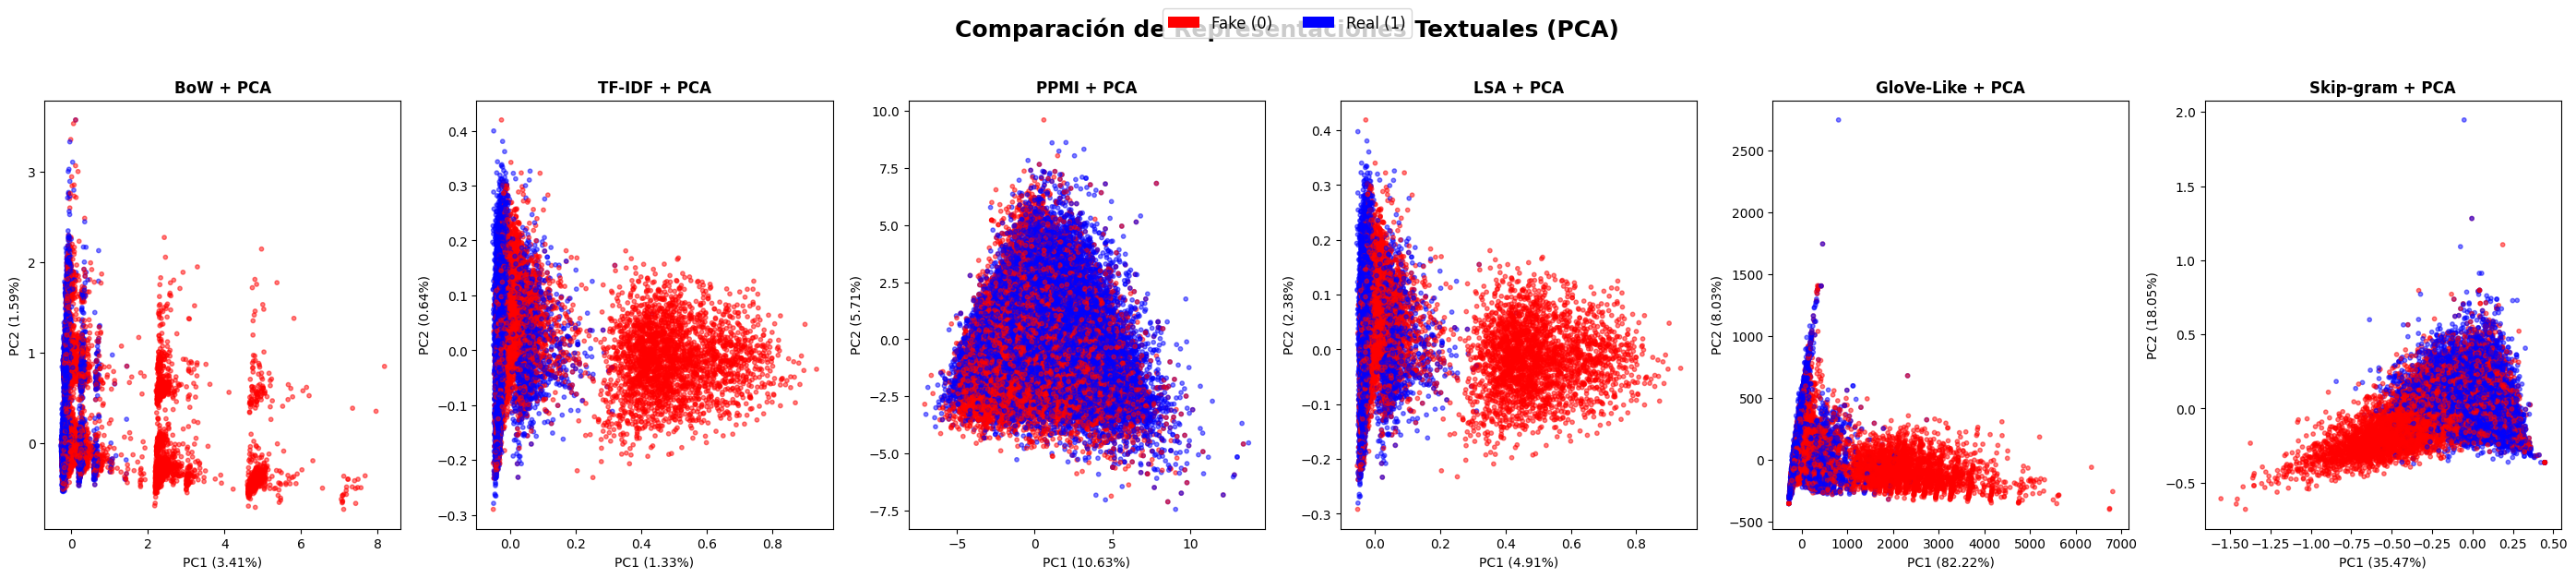

In [28]:
# Preparar figura con 6 representaciones × 1 técnica (PCA)
from matplotlib.patches import Patch


fig, axes = plt.subplots(1, 6, figsize=(28, 6))
fig.suptitle('Comparación de Representaciones Textuales (PCA)', 
             fontsize=18, fontweight='bold', y=1.02)

labels_array = np.array(labels)
colors = ['red' if label == 0 else 'blue' for label in labels_array]

representations = [
    ('BoW', bow_matrix.toarray()),
    ('TF-IDF', tfidf_matrix.toarray()),
    ('PPMI', ppmi_doc_matrix),
    ('LSA', lsa_doc_matrix),
    ('GloVe-Like', glove_doc_matrix),
    ('Skip-gram', skipgram_doc_matrix)
]

for col, (name, matrix) in enumerate(representations):
    print(f"\nProcesando {name}...")

    # PCA
    pca = PCA(n_components=2, random_state=42)
    pca_result = pca.fit_transform(matrix)

    axes[col].scatter(pca_result[:, 0], pca_result[:, 1],
                      c=colors, alpha=0.5, s=10)
    axes[col].set_title(f'{name} + PCA', fontweight='bold')
    axes[col].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
    axes[col].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')

# Agregar leyenda
legend_elements = [
    Patch(facecolor='red', label='Fake (0)'),
    Patch(facecolor='blue', label='Real (1)')
]
fig.legend(handles=legend_elements, loc='upper center',
           bbox_to_anchor=(0.5, 1.05), ncol=2, fontsize=12)

plt.tight_layout()
plt.savefig('comparacion_embeddings_pca.png', dpi=300, bbox_inches='tight')
print("\n✓ Gráfico guardado como 'comparacion_embeddings_pca.png'")
plt.show()

